# House Price Prediction Regression Project

## project goal

## Load LIbraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [3]:
df = pd.read_csv("Housing.csv")

## Area aur Price ke beech scatter plot dekhte hain

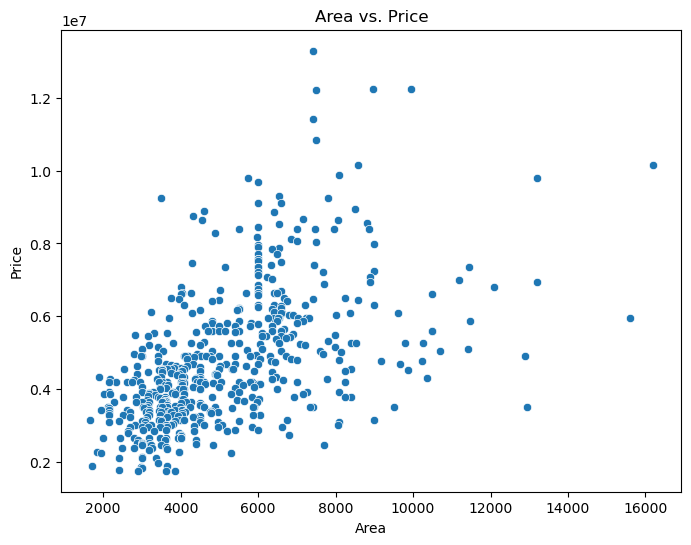

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(x='area', y='price', data=df) # assuming your DataFrame is named 'df'
plt.title('Area vs. Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

In [5]:
df = df[df['price'] > 1000000]

## Identify 'yes'/'no' columns

In [6]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
               'airconditioning', 'prefarea']

## Function to convert 'yes' to 1 and 'no' to 0

In [7]:
def yes_no_to_int(x):
    return x.map({'yes': 1, 'no': 0})

## Apply the function to all binary columns

In [8]:
df[binary_cols] = df[binary_cols].apply(yes_no_to_int)

## Check karein ki values badal gayin ya nahi

In [9]:
print("Binary encoded columns (first 5 rows):\n", df[binary_cols].head())

Binary encoded columns (first 5 rows):
    mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1
3         1          0         1                0                1         1
4         1          1         1                0                1         0


In [10]:
status_dummies = pd.get_dummies(df['furnishingstatus'], drop_first=True)

In [11]:
df = pd.concat([df, status_dummies], axis=1)

In [12]:
df = df.drop(['furnishingstatus'], axis=1)

In [13]:
print("Encoding ke baad data ke aakhri kuch columns:\n", df.tail())

Encoding ke baad data ke aakhri kuch columns:
        price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
540  1820000  3000         2          1        1         1          0   
541  1767150  2400         3          1        1         0          0   
542  1750000  3620         2          1        1         1          0   
543  1750000  2910         3          1        1         0          0   
544  1750000  3850         3          1        2         1          0   

     basement  hotwaterheating  airconditioning  parking  prefarea  \
540         1                0                0        2         0   
541         0                0                0        0         0   
542         0                0                0        0         0   
543         0                0                0        0         0   
544         0                0                0        0         0   

     semi-furnished  unfurnished  
540           False         True  
541            True    

In [14]:
from sklearn.model_selection import train_test_split


## Define X aur y

In [15]:
X = df.drop('price', axis=1) 
y = df['price']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (436, 13)
X_test shape: (109, 13)


In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
lr = LinearRegression()

## Model training shuru karna

In [20]:
lr.fit(X_train, y_train) 

print("Model training complete!")

Model training complete!


## Model Evaluation

In [21]:
y_pred = lr.predict(X_test)

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [23]:
r2 = r2_score(y_test, y_pred)

In [24]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} INR")

R-squared (R2) Score: 0.6529
Root Mean Squared Error (RMSE): 1,324,506.96 INR


## Residuals calculate karna

In [25]:
residuals = y_test - y_pred

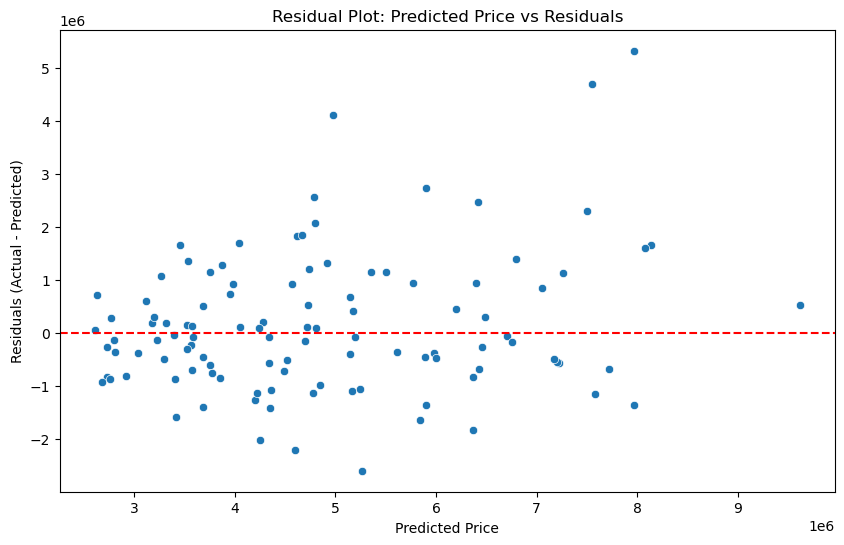

In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--') # Red line at y=0
plt.title('Residual Plot: Predicted Price vs Residuals')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

## Actual vs. Predicted Plot Banana

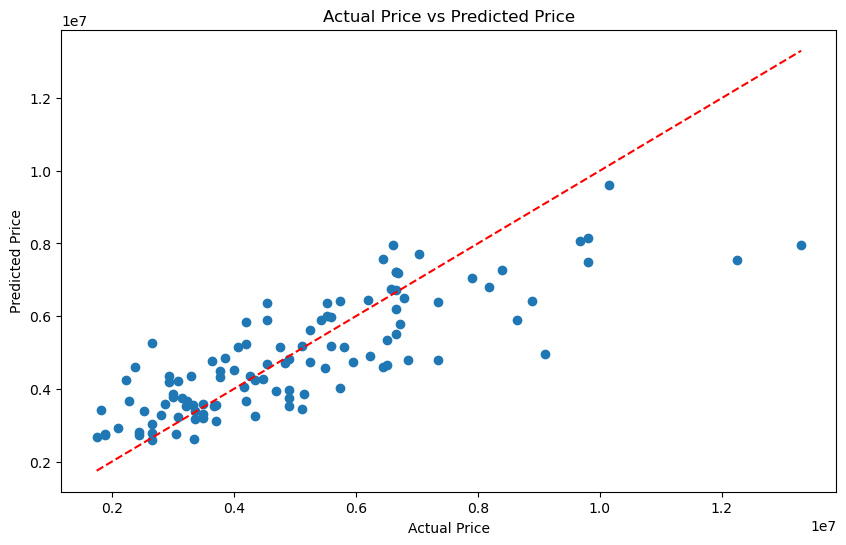

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Diagonal line (Perfect Prediction line)
plt.title('Actual Price vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

## Model Improvement

In [28]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

In [29]:
ridge_model = Ridge(alpha=1.0)

In [30]:
ridge_model.fit(X_train, y_train)

Ridge()

In [31]:
y_pred_ridge = ridge_model.predict(X_test)

In [32]:
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("\n--- Ridge Regression Results ---")
print(f"R-squared (R2) Score (Ridge): {r2_ridge:.4f}")
print(f"RMSE (Ridge): {rmse_ridge:,.2f} INR")


--- Ridge Regression Results ---
R-squared (R2) Score (Ridge): 0.6525
RMSE (Ridge): 1,325,320.44 INR


In [33]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

In [34]:
param_grid = {'alpha': [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]}

In [35]:
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')

In [36]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.1, 1.0, 5.0, 10.0, 50.0, 100.0]},
             scoring='r2')

In [37]:
best_alpha = grid_search.best_params_['alpha']
print(f"Best Alpha found: {best_alpha}")

Best Alpha found: 5.0


In [38]:
best_ridge_model = grid_search.best_estimator_
y_pred_tuned = best_ridge_model.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Ridge R-squared Score: {r2_tuned:.4f}")

Tuned Ridge R-squared Score: 0.6507


In [39]:
import pickle

# Model ko file mein save karna
filename = 'final_house_price_model.pkl'
pickle.dump(best_ridge_model, open(filename, 'wb')) 

print(f"Model saved as {filename}")

Model saved as final_house_price_model.pkl


--- Top 5 Most Important Features ---
            Feature   Coefficient
2         bathrooms  1.036185e+06
8   airconditioning  7.455173e+05
10         prefarea  5.903406e+05
7   hotwaterheating  5.403604e+05
3           stories  4.161369e+05


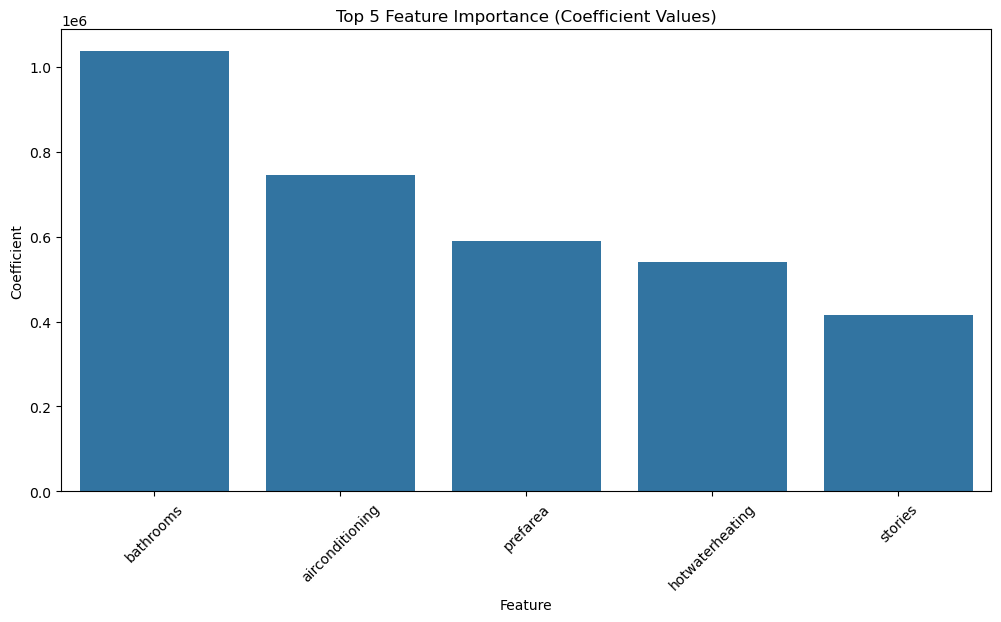

In [40]:
# Best Model ke coefficients nikalna (jo apne Step 8.2 mein banaya tha)
best_ridge_model = grid_search.best_estimator_ # Assuming you ran GridSearchCV

# Coefficients ko ek DataFrame mein store karna
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_ridge_model.coef_
})

# Coefficients ko unki absolute value ke hisaab se sort karna (Top 5 features)
coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
top_features = coefficients.sort_values(by='Absolute_Coefficient', ascending=False).head(5)

print("--- Top 5 Most Important Features ---")
print(top_features[['Feature', 'Coefficient']])

# Isko graph mein dekhna aur bhi informative hota hai
plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Coefficient', data=top_features)
plt.title('Top 5 Feature Importance (Coefficient Values)')
plt.xticks(rotation=45)
plt.show()

In [41]:
import pickle
# Assuming 'best_ridge_model' is your final model
filename = 'final_house_price_model.pkl'
pickle.dump(best_ridge_model, open(filename, 'wb')) 

print(f"Model saved as {filename}")

Model saved as final_house_price_model.pkl


## User Se Input Lena

In [42]:
hotwaterheating = 1 if hotwaterheating == 'Yes' else 0

NameError: name 'hotwaterheating' is not defined